# Incisos del 1 al 8.

### Importación de librerías.

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier


### Incisos 1 y 2.

### Importación de datos.

In [4]:
df = pd.read_csv('datos_limpios.csv')
df.head(2)

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,room_type_Hotel room,room_type_Private room,room_type_Shared room,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,97.0,2,...,0,0,0,0,1,0,0,0,0,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,160.0,3,...,0,0,0,0,1,0,0,0,0,0


### Estadísticas del objetivo.

In [5]:
df['price'].describe()

count    73549.000000
mean       769.542958
std       4326.270197
min          8.000000
25%        120.000000
50%        194.000000
75%        330.000000
max      50123.000000
Name: price, dtype: float64

### Manejo de NaN

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73549 entries, 0 to 164211
Data columns (total 67 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_listings_count                           73549 non-null  float64
 1   host_total_listings_count                     73549 non-null  float64
 2   latitude                                      73549 non-null  float64
 3   longitude                                     73549 non-null  float64
 4   accommodates                                  73549 non-null  int64  
 5   bathrooms                                     73549 non-null  float64
 6   bedrooms                                      73549 non-null  float64
 7   beds                                          73549 non-null  float64
 8   price                                         73549 non-null  float64
 9   minimum_nights                                73549 non-null  int

### Se reemplazará los NaN por las medianas.

In [7]:
df = df.fillna(df.median(numeric_only=True))

Las categorías se harán a partir de los cuartiles. Aquellas que estén debajo del cuartil 1 se denominarán 'Económicas', las que estén entre el primer y el tercer cuartil se denominarán 'Intermedia' y el resto 'Cara'.

### Se crea la categoría y se elimina la variable price. (Inciso 6)

In [8]:
categoria = []
for x in df['price']:
    if x <= 120:
        categoria.append('Económica')
    elif x < 330:
        categoria.append('Intermedia')
    else:
        categoria.append('Cara')
df = df.drop(columns=['price'])

### Separación de datos

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df, categoria, test_size=0.2, random_state=0, stratify=categoria)

### Escalamiento de los datos

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Encoder delas etiquetas.

In [11]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test  = encoder.transform(y_test)

### Cambio de formatos.

In [12]:
X_train = np.asarray(X_train).astype("float32")
X_test  = np.asarray(X_test).astype("float32")

y_train =np.asarray(y_train).astype("int32")
y_test  = np.asarray(y_test).astype("int32")

y_train = y_train.ravel()
y_test  = y_test.ravel()

### Modelos generados. (Inciso 3 y 4)

In [13]:
n_features = X_train.shape[1]
n_clases = 3

In [14]:
modelo_1 = Sequential([
    Input(shape=(n_features,)),
    Dense(units=64, activation="relu"),
    Dense(units=32, activation="relu"),
    Dense(units=n_clases, activation="softmax")
])

modelo_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_1.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7281 - loss: 0.6042 - val_accuracy: 0.7911 - val_loss: 0.4757
Epoch 2/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 956us/step - accuracy: 0.8117 - loss: 0.4328 - val_accuracy: 0.8356 - val_loss: 0.3817
Epoch 3/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 893us/step - accuracy: 0.8396 - loss: 0.3691 - val_accuracy: 0.8478 - val_loss: 0.3503
Epoch 4/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 913us/step - accuracy: 0.8531 - loss: 0.3372 - val_accuracy: 0.8509 - val_loss: 0.3391
Epoch 5/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8618 - loss: 0.3200 - val_accuracy: 0.8610 - val_loss: 0.3145
Epoch 6/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8656 - loss: 0.3070 - val_accuracy: 0.8596 - val_loss: 0.3187
Epoch 7/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 944us/step - accuracy: 0.8702 - loss: 0.2972 - val_accuracy: 0.8657 - val_loss: 0.3031
Epoch 8/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 916us/step - accuracy: 0.8737 - loss:

In [15]:
modelo_2 = Sequential([
    Input(shape=(n_features,)),
    Dense(units=128, activation="tanh"),
    Dropout(rate=0.3),
    Dense(units=64, activation="tanh"),
    Dense(units=32, activation="tanh"),
    Dense(units=n_clases, activation="softmax")
])

modelo_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6997 - loss: 0.6602 - val_accuracy: 0.7625 - val_loss: 0.5472
Epoch 2/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 994us/step - accuracy: 0.7609 - loss: 0.5378 - val_accuracy: 0.8061 - val_loss: 0.4477
Epoch 3/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7921 - loss: 0.4677 - val_accuracy: 0.8367 - val_loss: 0.3881
Epoch 4/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8102 - loss: 0.4264 - val_accuracy: 0.8434 - val_loss: 0.3602
Epoch 5/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8250 - loss: 0.3954 - val_accuracy: 0.8444 - val_loss: 0.3486
Epoch 6/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8345 - loss: 0.3727 - val_accuracy: 0.8562 - val_loss: 0.3261
Epoch 7/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8420 - loss: 0.3587 - val_accuracy: 0.8601 - val_loss: 0.3211
Epoch 8/50
1839/1839 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8479 - loss: 0.3451 

### Matrices de confusión (Inciso 5)

460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step


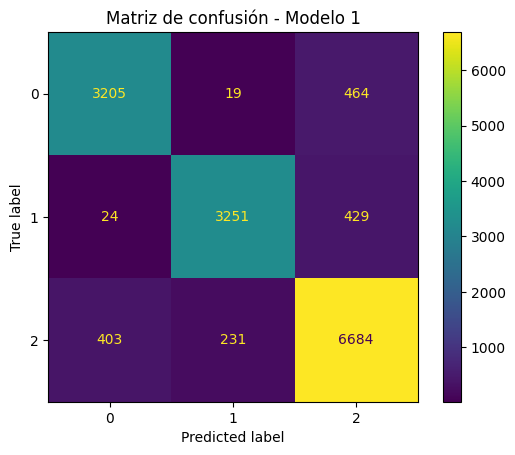

In [16]:
y_pred_1 = modelo_1.predict(X_test)
y_pred_1 = np.argmax(y_pred_1, axis=1)
cm_1 = confusion_matrix(y_test, y_pred_1)
ConfusionMatrixDisplay(cm_1).plot()
plt.title("Matriz de confusión - Modelo 1")
plt.show()

460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step


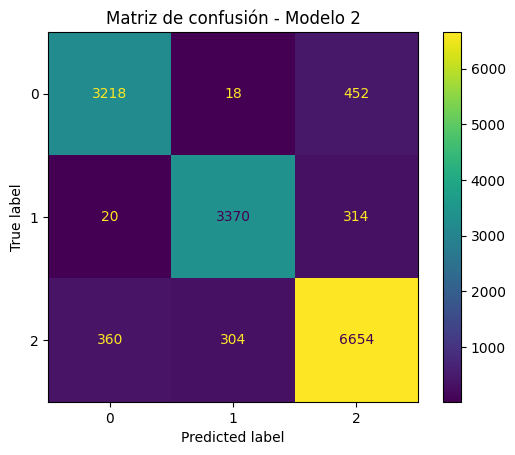

In [17]:
y_pred_2 = modelo_2.predict(X_test)
y_pred_2 = np.argmax(y_pred_2, axis=1)
cm_2 = confusion_matrix(y_test, y_pred_2)
ConfusionMatrixDisplay(cm_2).plot()
plt.title("Matriz de confusión - Modelo 2")
plt.show()

### Comparación de modelos (inciso 6).

El primer modelo fue más rápido, siedo entrenado 1:27 minutos, mientras que el segundo modelo se entrenó en 2:41 minutos.
El segundo modelo fue mejor para clasificando las etiquetas 1 y 2, el modelo 1 lo hizo solo un poco mejor en la etiqueta 1 (0.8497 contra 0.8479).
Por lo que el modelo 2 es la opción más llamativa a usar.

### Análisis de sobreajuste (Inciso 7).

1839/1839 ━━━━━━━━━━━━━━━━━━━━ 1s 594us/step


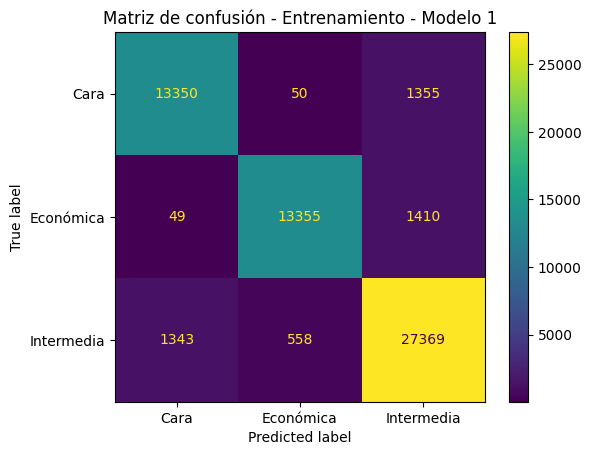

In [18]:
y_pred_train_1 = modelo_1.predict(X_train)
y_pred_train_1 = np.argmax(y_pred_train_1, axis=1)
cm_train_1 = confusion_matrix(y_train, y_pred_train_1)
ConfusionMatrixDisplay(confusion_matrix=cm_train_1, display_labels=encoder.classes_).plot()
plt.title("Matriz de confusión - Entrenamiento - Modelo 1")
plt.show()

1839/1839 ━━━━━━━━━━━━━━━━━━━━ 1s 545us/step


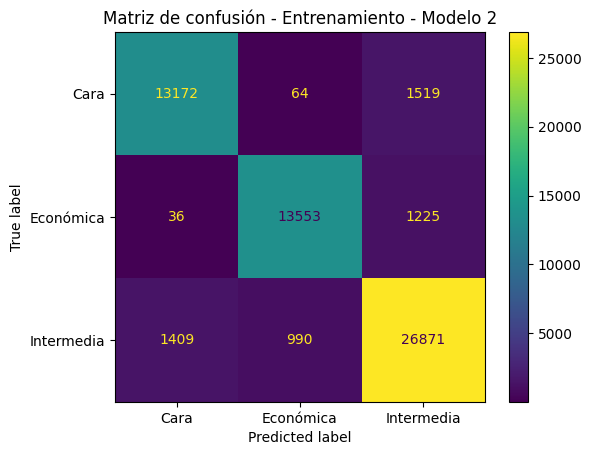

In [19]:
y_pred_train_2 = modelo_2.predict(X_train)
y_pred_train_2 = np.argmax(y_pred_train_2, axis=1)
cm_train_2 = confusion_matrix(y_train, y_pred_train_2)
ConfusionMatrixDisplay(confusion_matrix=cm_train_2, display_labels=encoder.classes_).plot()
plt.title("Matriz de confusión - Entrenamiento - Modelo 2")
plt.show()

Ningún modelo muestra sobreajuste, ya que la diferencia máxima de ambos respecto al conjunto de prueba es del 2%.

### Modelo elejido (Inciso 8)

In [ ]:
modelo_grid = KerasClassifier(
    model=lambda n1=128, n2=64, n3=32, dropout=0.3: Sequential([
        Input(shape=(n_features,)),
        Dense(n1, activation="tanh"),
        Dropout(dropout),
        Dense(n2, activation="tanh"),
        Dense(n3, activation="tanh"),
        Dense(n_clases, activation="softmax")
    ]),
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam,
    metrics=["accuracy"],
    verbose=0
)

param_grid = {
    "model__n1": [32, 64],
    "model__n2": [16, 32],
    "model__n3": [16, 32],
    "model__dropout": [0.2, 0.3],
    "optimizer__learning_rate": [0.0005],
    "epochs": [30],
    "batch_size": [16]
}

grid = GridSearchCV(
    estimator=modelo_grid,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=1,
    verbose=1
)

In [23]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


KeyboardInterrupt: 

In [ ]:
print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy:", grid.best_score_)

In [ ]:
mejor_modelo_2 = grid.best_estimator_
print("Accuracy en test:", mejor_modelo_2.score(X_test, y_test))